In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\Gulfam\Downloads\powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X=df.drop("PE", axis =1)
y=df["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# Split out daat
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [10]:
import torch
import torch.nn as nn
X_train_tensor= torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor= torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [11]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [12]:
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32)

In [31]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            ##1 hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2 hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer
            nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)

            
        

In [32]:
import torch. optim as optim
model= ANN()

#Loss function
Criterion= nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [33]:
# Training ANN
train_loss=[]
validation_loss=[]
best_val_loss=float("inf")
epochs=80
for epoch in range(epochs):
    model.train()
    runing_loss=0.0 

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs=model(xb)
        loss=Criterion(outputs,yb)
        loss.backward()
        optimizer.step()

        runing_loss+=loss.item()
    epoch_train_loss=runing_loss/len(train_loader)
    train_loss.append(epoch_train_loss)

    #validation 
    model.eval()
    runing_val_loss=0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs=model(xb)
            loss=Criterion(outputs,yb)
            runing_val_loss+=loss
            
    epoch_val_loss=runing_val_loss/len(test_loader)
    validation_loss.append(epoch_val_loss) 

    if epoch_val_loss< best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

    print(f" {epoch+1}/{epochs} ==> Train loss {epoch_train_loss} & Validation loss {epoch_test_loss}")

 1/80 ==> Train loss 206185.0091796875 & Validation loss 19.01448631286621
 2/80 ==> Train loss 195598.79479166667 & Validation loss 19.01448631286621
 3/80 ==> Train loss 156589.44296875 & Validation loss 19.01448631286621
 4/80 ==> Train loss 98010.91580403646 & Validation loss 19.01448631286621
 5/80 ==> Train loss 52541.52872721354 & Validation loss 19.01448631286621
 6/80 ==> Train loss 29592.378198242186 & Validation loss 19.01448631286621
 7/80 ==> Train loss 18934.276892089845 & Validation loss 19.01448631286621
 8/80 ==> Train loss 13622.73301595052 & Validation loss 19.01448631286621
 9/80 ==> Train loss 10006.40867207845 & Validation loss 19.01448631286621
 10/80 ==> Train loss 7293.45918375651 & Validation loss 19.01448631286621
 11/80 ==> Train loss 5065.139053344727 & Validation loss 19.01448631286621
 12/80 ==> Train loss 3423.1424087524415 & Validation loss 19.01448631286621
 13/80 ==> Train loss 2306.0836634318034 & Validation loss 19.01448631286621
 14/80 ==> Train lo

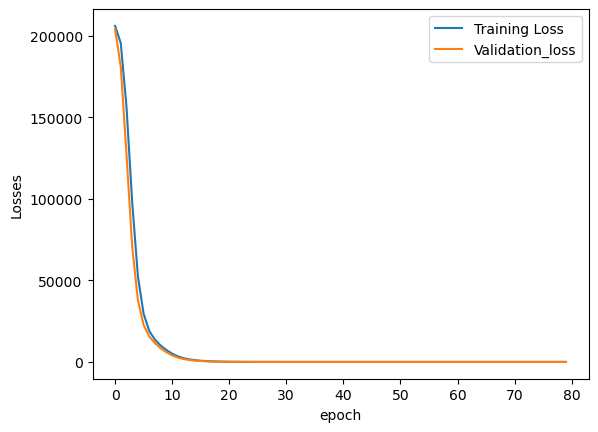

In [34]:
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({"Training_loss": train_loss, "Validation_loss":validation_loss})

plt.plot(loss_df["Training_loss"], label="Training Loss")
plt.plot(loss_df["Validation_loss"], label="Validation_loss")
plt.xlabel("epoch")
plt.ylabel("Losses")
plt.legend()

In [35]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [39]:
# Evaluation
with torch.no_grad():
   train_eval= model(X_train_tensor)
   test_eval=model(X_test_tensor)

   train_loss=Criterion(train_eval, y_train_tensor)
   test_loss=Criterion(test_eval, y_test_tensor)
print(f"Traine MSE loss {train_loss}")
print(f"Test MSE loss {test_loss}")

Traine MSE loss 20.57649803161621
Test MSE loss 19.056638717651367
